### PartA

### 1.1.A


###### P(Planned to Purchase and Placed Order) = Number of People who Planned to Purchase and Placed Order/ Total Number of People 
###### P(Planned to Purchase and Placed Order) = 400 / 2000
###### P(Planned to Purchase and Placed Order) = 1/5 = 0.2 = 20%


 


### 1.1.B

#### P(Placed Order | Planned to Purchase) = Number of People who Planned to Purchase and Placed Order/ Number of People who planned to purchase = 400 / 500 = 0. 8 = 80%

   ### 2

In [7]:
from scipy.stats import binom

total_items = 10
defective = 0.05  

# function to calculate binomial mass function. 
def binomial_pmf(k, n, p):
    return binom.pmf(k, n, p)

prob_none_defective = binomial_pmf(0, total_items, defective)
print(f"2.A. Probability that none of the items are defective: {prob_none_defective}")

prob_one_defective = binomial_pmf(1, total_items, defective)
print(f"2.B. Probability that exactly one of the items is defective: {prob_one_defective}")

prob_two_or_fewer_defective = binomial_pmf(2, total_items, defective) + binomial_pmf(1, total_items, defective) + binomial_pmf(0, total_items, defective)
print(f"2.C. Probability that two or fewer of the items are defective: {prob_two_or_fewer_defective}")

prob_three_or_more_defective = 1 - prob_two_or_fewer_defective
print(f"2.D. Probability that three or more of the items are defective: {prob_three_or_more_defective}")



2.A. Probability that none of the items are defective: 0.5987369392383789
2.B. Probability that exactly one of the items is defective: 0.31512470486230504
2.C. Probability that two or fewer of the items are defective: 0.9884964426207035
2.D. Probability that three or more of the items are defective: 0.011503557379296536


### 3

In [21]:
import math

#3.A. 
lambda_value = 3  #car sold per week
probability_some_cars = 1 - math.exp(-lambda_value)
print(f"3.A. Probability of selling some cars: {probability_some_cars}")

#3.B.
probability_2_or_more_less_than_5 = sum(math.exp(-lambda_value) * lambda_value**k / math.factorial(k) for k in range(2, 5))
 
print(f"3.B. Probability of selling 2 or more but less than 5 cars: {probability_2_or_more_less_than_5}")



3.A. Probability of selling some cars: 0.950212931632136
3.B. Probability of selling 2 or more but less than 5 cars: 0.6161149710523164


### 3.3.C 

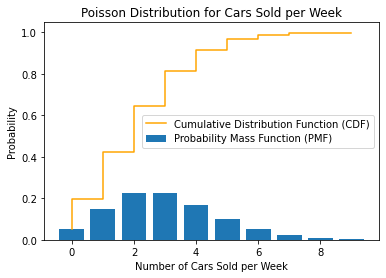

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson

x = np.arange(0, 10)  # Number of cars sold per week
pmf_values = poisson.pmf(x, lambda_value)
cdf_values = np.cumsum(pmf_values)

plt.bar(x, pmf_values, label='Probability Mass Function (PMF)')
plt.step(x, cdf_values, label='Cumulative Distribution Function (CDF)', color='orange')
plt.xlabel('Number of Cars Sold per Week')
plt.ylabel('Probability')
plt.title('Poisson Distribution for Cars Sold per Week')
plt.legend()
plt.show()


### 4

import math

n = 3  # number of orders
p = 0.868  # probability of correct recognition

probability_all_correct = math.comb(n, n) * p**n * (1-p)**0
print(f"4.A.Probability that all three orders will be recognized correctly: {probability_all_correct}")

probability_none_correct = (1-p)**n
print(f"4.B. Probability that none of the three orders will be recognized correctly: {probability_none_correct}")

probability_at_least_two_correct = sum(math.comb(n, k) * p**k * (1-p)**(n-k) for k in range(2, n+1))
print(f"4.C.Probability that at least two of the three orders will be recognized correctly: {probability_at_least_two_correct}")


### 5

### Real life industry scenario

#### real-life industry scenario for car purchase recommendation 
#### The dealership can aims to improve its sales performance and customer satisfaction by tailoring its inventory to meet customer preferences

#### Descriptive Statistics:

##### Use summary statistics to understand the central tendency and variability of key variables (e.g., average price, most popular models).

#### Inferential Statistics:

##### Conduct hypothesis tests to determine if certain features significantly impact sales.
Utilize confidence intervals to estimate the range within which key metrics, such as average sales, are likely to fall.

#### Correlation Analysis:

##### Analyze correlations between different variables (e.g., price and sales volume) to identify potential relationships.

#### Regression Analysis:

##### Build regression models to predict sales based on various features, helping the dealership understand the impact of each factor.

#### Customer Segmentation:

##### Apply clustering techniques to segment customers based on their preferences, allowing for targeted marketing and inventory management.

##### By applying these techniques, the dealership can make informed decisions about inventory management, pricing, and marketing strategies. For example, they may discover that a particular car model is more popular among young professionals and adjust their advertising efforts accordingly. Moreover, insights into the correlation between pricing and sales can guide the dealership in setting competitive yet profitable prices.


### PartB

In [60]:
import pandas as pd

# Read the data
df = pd.read_csv('Basketball.csv')

print(df.info())

# Handle missing values
df = df.dropna()
print("info:Drop null Successful")

#removing non numeric values 

df['WonGames'] = pd.to_numeric(df['WonGames'], errors='coerce')
df['PlayedGames'] = pd.to_numeric(df['PlayedGames'], errors='coerce')
df['BasketScored'] = pd.to_numeric(df['BasketScored'], errors='coerce')
df['BasketGiven'] = pd.to_numeric(df['BasketGiven'], errors='coerce')

#clean team launch to select only years

df['TeamLaunch'] = df['TeamLaunch'].str[:4]
df = df.dropna()
#print(df)
# Calculate win percentage
df['WinPercentage'] = df['WonGames'].astype(int) / df['PlayedGames'].astype(int) * 100
#print("info:winPercentage")

# Calculate goal difference
df['GoalDifference'] = df['BasketScored'].astype(int) - df['BasketGiven'].astype(int)
#print("info:GoalDifference")
#Calculate team age
current_year = 2023  # You can update this with the current year
df['TeamAge'] = current_year - df['TeamLaunch'].astype(int)
#print("info:TeamAge")
# Final Dataset
#print(df)
final_dataset = df.copy()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Team                 61 non-null     object
 1   Tournament           61 non-null     int64 
 2   Score                61 non-null     object
 3   PlayedGames          61 non-null     object
 4   WonGames             61 non-null     object
 5   DrawnGames           61 non-null     object
 6   LostGames            61 non-null     object
 7   BasketScored         61 non-null     object
 8   BasketGiven          61 non-null     object
 9   TournamentChampion   61 non-null     object
 10  Runner-up            61 non-null     object
 11  TeamLaunch           61 non-null     object
 12  HighestPositionHeld  61 non-null     int64 
dtypes: int64(2), object(11)
memory usage: 6.3+ KB
None
info:Drop null Successful


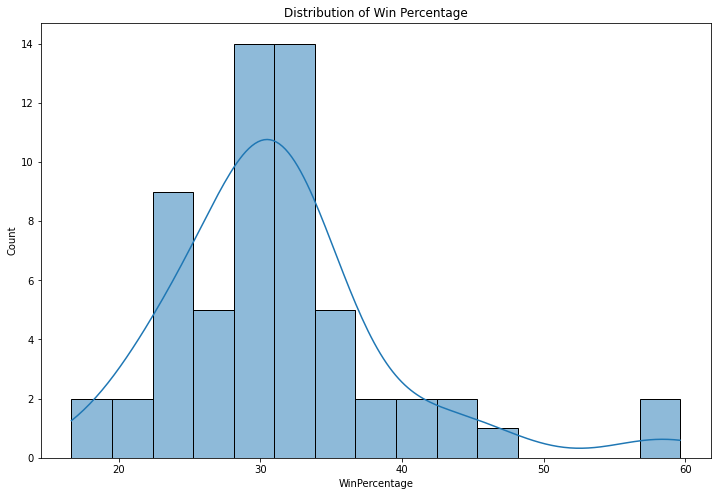

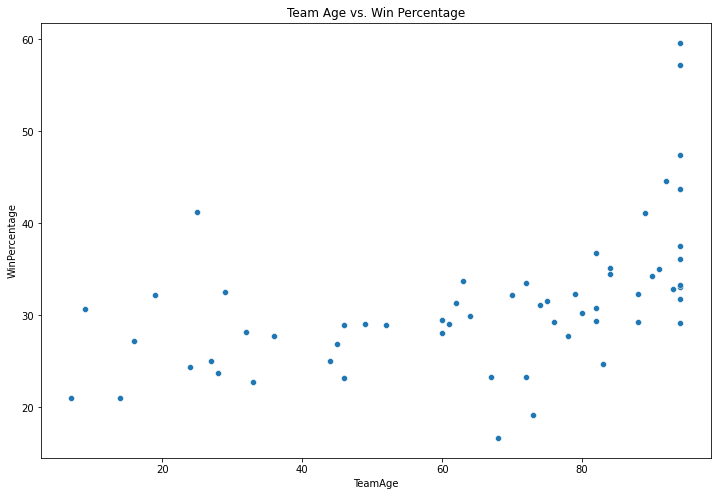

Best Performing Team: Team 1
Oldest Team: Team 1
Team with the Highest Goals: Team 1
Team with the Lowest Performance: Team 60


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate Analysis
# Explore the distribution of key variables
plt.figure(figsize=(12, 8))
sns.histplot(df['WinPercentage'], kde=True)
plt.title('Distribution of Win Percentage')
plt.show()

# Bivariate Analysis
# Explore relationships between variables
plt.figure(figsize=(12, 8))
sns.scatterplot(x='TeamAge', y='WinPercentage', data=df)
plt.title('Team Age vs. Win Percentage')
plt.show()


# Use clustering techniques
from sklearn.cluster import KMeans

X = df[['WinPercentage', 'GoalDifference']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)


# Best performing team
best_team = df[df['WinPercentage'] == df['WinPercentage'].max()]['Team'].values[0]
print(f"Best Performing Team: {best_team}")

# Oldest team
oldest_team = df[df['TeamAge'] == df['TeamAge'].max()]['Team'].values[0]
print(f"Oldest Team: {oldest_team}")

# Team with the highest goals
highest_goals_team = df[df['BasketScored'] == df['BasketScored'].max()]['Team'].values[0]
print(f"Team with the Highest Goals: {highest_goals_team}")

# Team with the lowest performance (you can define performance based on your metrics)
lowest_performance_team = df[df['WinPercentage'] == df['WinPercentage'].min()]['Team'].values[0]
print(f"Team with the Lowest Performance: {lowest_performance_team}")

# Interactive Visualizations (using Plotly)
import plotly.express as px

fig = px.scatter(df, x='WinPercentage', y='GoalDifference', color='Cluster', hover_data=['Team'])
fig.update_layout(title='Win Percentage vs. Goal Difference')
fig.show()


## PartB.3. Suggestion

### Quality
#### i.Implement a data validation process using a data quality.For example check for invalid values like string in int column, consitency and completeness.
#### ii. Integrate data from various sources such as social media sentiment analysis.
#### iii. Conduct regular audits to ensure data validity and reliability



### PartC

### Task#1

In [33]:
import pandas as pd


file_path = 'CompanyX_EU.csv'
df = pd.read_csv(file_path)
#print(df)

             Startup             Product Funding             Event  \
0             2600Hz          2600hz.com     NaN   Disrupt SF 2013   
1               3DLT            3dlt.com   $630K  Disrupt NYC 2013   
2        3DPrinterOS     3dprinteros.com     NaN   Disrupt SF 2016   
3         3Dprintler      3dprintler.com     $1M   Disrupt NY 2016   
4    42 Technologies  42technologies.com     NaN  Disrupt NYC 2013   
..               ...                 ...     ...               ...   
657           Zivity          zivity.com     $8M         TC40 2007   
658           Zmorph        zmorph3d.com     $1M                 -   
659           Zocdoc          zocdoc.com   $223M         TC40 2007   
660             Zula         zulaapp.com   $3.4M   Disrupt SF 2013   
661           Zumper          zumper.com  $31.5M   Disrupt SF 2012   

              Result OperatingState  
0         Contestant      Operating  
1         Contestant         Closed  
2         Contestant      Operating  
3    Au

In [34]:
#Task2 

# A. 
print(df.dtypes)

# B.
print(df.isnull().sum())

#Task 3 Data Exploration 

# A. 
df1 = df.dropna()
print(df1['Funding'])
# B. 
df1.loc[:, 'Funds_in_million'] = df1['Funding'].apply(lambda x: float(x[1:-1])/1000 if x[-1] == 'K' else (float(x[1:-1])*1000 if x[-1] == 'B' else float(x[1:-1])))

print(df1['Funds_in_million'])

Startup           object
Product           object
Funding           object
Event             object
Result            object
OperatingState    object
dtype: object
Startup             0
Product             6
Funding           214
Event               0
Result              0
OperatingState      0
dtype: int64
1       $630K
3         $1M
5      $19.3M
6        $29M
10      $1.8M
        ...  
657       $8M
658       $1M
659     $223M
660     $3.4M
661    $31.5M
Name: Funding, Length: 446, dtype: object
1        0.63
3        1.00
5       19.30
6       29.00
10       1.80
        ...  
657      8.00
658      1.00
659    223.00
660      3.40
661     31.50
Name: Funds_in_million, Length: 446, dtype: float64


C:\Users\pramod.pal\Anaconda3\lib\site-packages\pandas\core\indexing.py:1597: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\pramod.pal\Anaconda3\lib\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



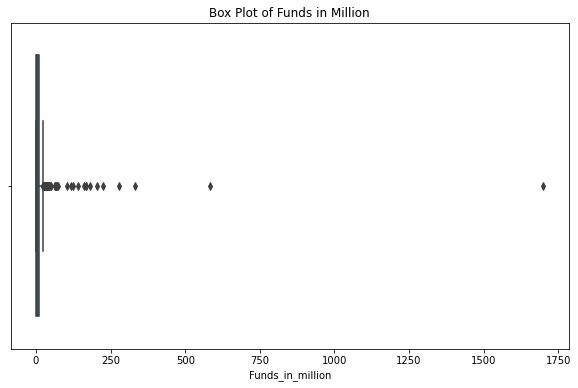

Number of outliers greater than the upper fence: 60
Operating State Frequency:
Operating    319
Acquired      66
Closed        57
Ipo            4
Name: OperatingState, dtype: int64


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Funds_in_million', data=df1)
plt.title('Box Plot of Funds in Million')
plt.show()

# D. 
upper_fence = df1['Funds_in_million'].quantile(0.75) + 1.5 * (df1['Funds_in_million'].quantile(0.75) - df1['Funds_in_million'].quantile(0.25))
num_outliers = df1[df1['Funds_in_million'] > upper_fence].shape[0]
print(f'Number of outliers greater than the upper fence: {num_outliers}')

# E.
operating_state_counts = df1['OperatingState'].value_counts()
print('Operating State Frequency:')
print(operating_state_counts)


In [58]:
from scipy.stats import ttest_ind

operating_funds = df1[df1['OperatingState'] == 'Operating']['Funds_in_million']
closed_funds = df1[df1['OperatingState'] == 'Closed']['Funds_in_million']

# C. 
t_stat, p_value = ttest_ind(operating_funds, closed_funds)
print(f'T-statistic: {t_stat}, P-value: {p_value}')

# D. 
df.info()
df_copy = df.copy()
df_copy.info()

# E. 
result_counts = df_copy['Result'].value_counts()
print('Result Frequency:')
print(result_counts)

# F. 
winners_operating_percentage = (df_copy[(df_copy['Result'] == 'Winner') & (df_copy['OperatingState'] == 'Operating')].shape[0] / df_copy[df_copy['Result'] == 'Winner'].shape[0]) * 100
contestants_operating_percentage = (df_copy[(df_copy['Result'] == 'Contestant') & (df_copy['OperatingState'] == 'Operating')].shape[0] / df_copy[df_copy['Result'] == 'Contestant'].shape[0]) * 100

# G.
print("info:before disrupt events")
#df_copy['Event'] = df_copy['Event'].str.split().str[-1]
#df_copy['Event'] = pd.to_numeric(df_copy['Event'], errors='coerce')
#df_copy = df_copy.dropna() #clean invalid event values
disrupt_events = df_copy[(df_copy['Event'].str.contains('disrupt', case=False)) & (df_copy['Event'].str.split().str[-1].replace('-', 0).astype(int) >= 2013)]
print(disrupt_events)


T-statistic: 1.1382924515740138, P-value: 0.25572701885629406
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662 entries, 0 to 661
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Startup         662 non-null    object
 1   Product         656 non-null    object
 2   Funding         448 non-null    object
 3   Event           662 non-null    object
 4   Result          662 non-null    object
 5   OperatingState  662 non-null    object
dtypes: object(6)
memory usage: 31.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662 entries, 0 to 661
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Startup         662 non-null    object
 1   Product         656 non-null    object
 2   Funding         448 non-null    object
 3   Event           662 non-null    object
 4   Result          662 non-null    object
 5   OperatingState  662 non-